In [1]:
import numpy as np

import cv2


import cv2
import numpy as np

def mask_centroids(mask: np.ndarray):
    """
    Compute centroids of all connected blobs in a binary mask.

    Returns:
        List of (cx, cy) as floats
    """
    if mask.ndim != 2:
        raise ValueError("Mask must be 2D")

    # Ensure binary mask
    mask_bin = (mask > 0).astype(np.uint8)

    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_bin)

    # Skip background (label 0)
    return [tuple(centroids[i]) for i in range(1, num_labels)]


import tifffile as tf
masks = tf.imread("/home/aman.kukde/cilia_ai/data/masks.tif")
images = tf.imread("/home/aman.kukde/cilia_ai/data/images.tif")


centroids_0 = [mask_centroids(m[0]) for m in masks]
centroids_1 = [mask_centroids(m[1]) for m in masks]
print(len(centroids_0))
print(len(centroids_1))

4365
4365


In [2]:
import numpy as np

# centroids_0 and centroids_1 are lists of lists
# Step 1: find slices where either channel is empty
valid_idx = [i for i, (c0, c1) in enumerate(zip(centroids_0, centroids_1)) if len(c0) > 0 and len(c1) > 0]

print(f"Keeping {len(valid_idx)} slices with valid centroids")

# Step 2: keep only valid slices in masks/images/centroids
mask_clean = masks[valid_idx]
images_clean = images[valid_idx]
centroids_0_clean = [centroids_0[i] for i in valid_idx]
centroids_1_clean = [centroids_1[i] for i in valid_idx]

# Step 3: zip centroids per slice into shape (N, 2, ?)
# Use dtype=object to allow variable-length inner lists
centroids_final = np.array([ [c0, c1] for c0, c1 in zip(centroids_0_clean, centroids_1_clean) ], dtype=object)

print("Shape of centroids_final:", centroids_final.shape)
# Example access: centroids_final[i][0] = channel 0 centroids for slice i
#                 centroids_final[i][1] = channel 1 centroids for slice i


Keeping 2697 slices with valid centroids
Shape of centroids_final: (2697, 2)


In [6]:
import numpy as np

# Save masks and images
np.save("../data/prompts/mask_clean.npy", mask_clean)
np.save("../data/prompts/images_clean.npy", images_clean)

# Save centroids_final (dtype=object)
np.save("../data/prompts/centroids_final.npy", centroids_final)
# Save valid indices too
np.save("../data/prompts/valid_idx.npy", valid_idx)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..65535].


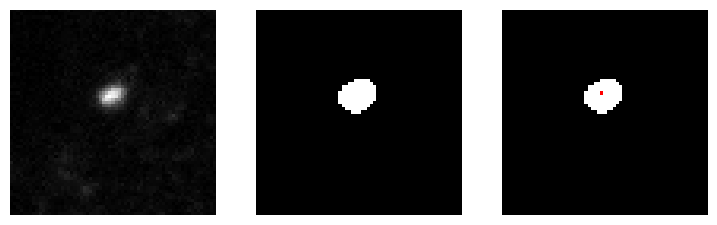

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

i = 10 # index of the image/mask to visualize
ov = np.stack([masks[i,0]]*3, -1)

# get first blob centroid
cx, cy = centroids_0[i][0]          # (x, y) from OpenCV
r, c = int(cy), int(cx)             # row = y, col = x

# mark pixel
ov[r, c] = [255, 0, 0]

plt.figure(figsize=(9,3))
plt.subplot(131); plt.imshow(images[i,0], cmap='gray'); plt.axis('off')
plt.subplot(132); plt.imshow(masks[i,0], cmap='gray'); plt.axis('off')
plt.subplot(133); plt.imshow(ov); plt.axis('off')
plt.show()
